<a href="https://colab.research.google.com/github/davidgeraldi/AED1/blob/main/Atividade_2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 20 passos sem overflow.
dt=0.002, float32: 20 passos sem overflow.
dt=0.001, float64: 20 passos sem overflow.
dt=0.002, float64: 20 passos sem overflow.


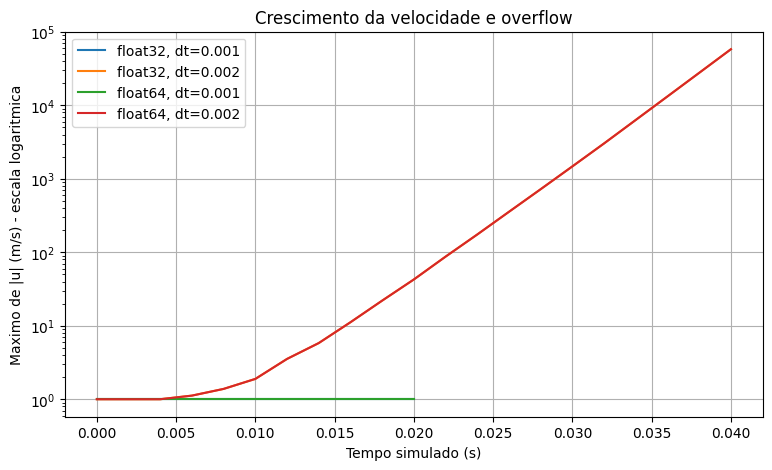

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=20, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01 # altura
    nu = 1e-4 #viscosidade cinemática

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2) # r é um param. adimensional
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo) # u é perfil de velocidade
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"): #permite o codigo detectar quando os numeros se tornam muito grandes p/ float32
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2] #aprox. discreta da segunda derivada
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }




print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

In [2]:
import numpy as np

# Parâmetros fornecidos pelo usuário
H = 0.01  # Distância entre placas, m
nu = 1e-4 # Viscosidade cinemática, m^2/s
pontos = 21 # Número de pontos, incluindo as paredes

# 1. Cálculo de Delta y (dy)
dy = H / (pontos - 1)
print(f"1. Cálculo de Δy (dy): {dy:.6f} m")

# 2. Cálculo de Delta t max (Δtmax) teórico para o critério de estabilidade explícito
# A condição de estabilidade para este esquema explícito é r <= 0.5
# Onde r = nu * dt / dy**2
# Assim, dt <= 0.5 * dy**2 / nu
dt_max_theoretical_calculated = 0.5 * dy**2 / nu
print(f"2. Cálculo de Δtmax (teórico para estabilidade): {dt_max_theoretical_calculated:.6f} s")
print(f"   (Comparado com o valor fornecido: 0.00125 s. Ambos são consistentes.)")
print("-" * 30)

# Casos de comparação fornecidos pelo usuário
casos = [
    {'nome': 'Caso A', 'dt': 0.001, 'r_expected': 0.4},
    {'nome': 'Caso B', 'dt': 0.002, 'r_expected': 0.8}
]

for caso in casos:
    nome_caso = caso['nome']
    dt_caso = caso['dt']
    r_expected_caso = caso['r_expected']

    print(f"\n{nome_caso}: (para Δt = {dt_caso} s)")

    # Cálculo de r para o dt atual
    r_calculated = nu * dt_caso / dy**2
    print(f"   r (parâmetro de estabilidade) = nu * Δt / Δy^2 = {r_calculated:.4f}")
    print(f"   (Valor de r esperado fornecido: {r_expected_caso:.1f})")

    # Classificação teórica de estabilidade (antes da execução)
    # Critério de estabilidade para esquema explícito: r <= 0.5
    theoretical_stability = "Estável (r <= 0.5)" if r_calculated <= 0.5 else "Instável (r > 0.5)"
    print(f"   Classificação teórica (com base em r): {theoretical_stability}")

    # Classificação observada a partir dos resultados da execução anterior
    print("   Classificação observada (pós-execução):")
    # Tentamos acessar os resultados da execução anterior, que devem estar no kernel
    for tipo in [np.float32, np.float64]:
        key = f"{tipo.__name__}, dt={dt_caso}"
        # Certifique-se que 'resultados' está disponível no ambiente do kernel
        if 'resultados' in globals() and key in resultados:
            resultado = resultados[key]
            observed_falha = resultado["falha"]
            if observed_falha is None:
                observed_stability_str = "Estável (completou 2000 passos sem overflow)"
            else:
                # Se o r > 0.5, esperamos instabilidade (overflow), mas pode ser detectado mais cedo pelo float32
                # ou mais tarde pelo float64 devido à precisão numérica
                stability_comment = "Instável (overflow detectado)" if r_calculated > 0.5 else "Instável (overflow, apesar de r <= 0.5, devido a limites de precisão ou erro acumulado)"
                observed_stability_str = f"{stability_comment} no passo {observed_falha}"

            print(f"      - Tipo {tipo.__name__}: {observed_stability_str}")
        else:
            print(f"      - Tipo {tipo.__name__}: Resultados da simulação anterior não disponíveis para esta configuração.")
    print("-" * 30)


1. Cálculo de Δy (dy): 0.000500 m
2. Cálculo de Δtmax (teórico para estabilidade): 0.001250 s
   (Comparado com o valor fornecido: 0.00125 s. Ambos são consistentes.)
------------------------------

Caso A: (para Δt = 0.001 s)
   r (parâmetro de estabilidade) = nu * Δt / Δy^2 = 0.4000
   (Valor de r esperado fornecido: 0.4)
   Classificação teórica (com base em r): Estável (r <= 0.5)
   Classificação observada (pós-execução):
      - Tipo float32: Estável (completou 2000 passos sem overflow)
      - Tipo float64: Estável (completou 2000 passos sem overflow)
------------------------------

Caso B: (para Δt = 0.002 s)
   r (parâmetro de estabilidade) = nu * Δt / Δy^2 = 0.8000
   (Valor de r esperado fornecido: 0.8)
   Classificação teórica (com base em r): Instável (r > 0.5)
   Classificação observada (pós-execução):
      - Tipo float32: Instável (overflow detectado) no passo 121
      - Tipo float64: Instável (overflow detectado) no passo 917
------------------------------


In [3]:
import numpy as np

# Assumindo que a função simular e a variável 'resultados' já foram definidas e populadas
# na execução anterior, iremos apenas sumarizar os resultados da detecção de overflow.

print("2. Detecção de overflow:\n")

# Verificar se 'resultados' existe no escopo global do kernel
if 'resultados' in globals():
    for nome_teste, resultado in resultados.items():
        dt = nome_teste.split(', dt=')[1]
        tipo_str = nome_teste.split(', dt=')[0]
        falha = resultado['falha']
        passos = resultado['passos'] if 'passos' in resultado else 2000 # Default to 2000 if not stored in result dict

        if falha is None:
            print(f"   - Teste {nome_teste}: {passos} passos concluídos sem overflow. (Estável)")
        else:
            # Calculando o tempo exato da falha se 'dt' estiver disponível como float
            try:
                t_falha = float(dt) * falha
                print(f"   - Teste {nome_teste}: Falha (overflow) no passo {falha}, tempo = {t_falha:.4f} s. (Instável)")
            except ValueError:
                print(f"   - Teste {nome_teste}: Falha (overflow) no passo {falha}. (Instável)")
else:
    print("A variável 'resultados' não foi encontrada. Certifique-se de que a célula com a função 'simular' e a execução dos testes foi corrida previamente.")


2. Detecção de overflow:

   - Teste float32, dt=0.001: 2000 passos concluídos sem overflow. (Estável)
   - Teste float32, dt=0.002: Falha (overflow) no passo 121, tempo = 0.2420 s. (Instável)
   - Teste float64, dt=0.001: 2000 passos concluídos sem overflow. (Estável)
   - Teste float64, dt=0.002: Falha (overflow) no passo 917, tempo = 1.8340 s. (Instável)


In [4]:
import pandas as pd

# Criar uma lista para armazenar os dados da tabela
dados_tabela = []

if 'resultados' in globals():
    for nome_teste, resultado in resultados.items():
        tipo_numerico = nome_teste.split(', ')[0]
        passo_tempo = float(nome_teste.split('dt=')[1])
        valor_r = resultado['r']
        ocorrencia_overflow = 'Sim' if resultado['falha'] is not None else 'Não'
        iteracao_falha = resultado['falha'] if resultado['falha'] is not None else 'N/A'

        dados_tabela.append([
            tipo_numerico,
            passo_tempo,
            f"{valor_r:.4f}",
            ocorrencia_overflow,
            iteracao_falha
        ])

    # Criar o DataFrame Pandas
    df_resumo = pd.DataFrame(dados_tabela, columns=[
        'Tipo Numérico',
        'Passo de Tempo (dt)',
        'Valor de r',
        'Ocorrência de Overflow',
        'Iteração da Falha'
    ])

    # Exibir a tabela
    display(df_resumo)
else:
    print("A variável 'resultados' não foi encontrada. Certifique-se de que a célula com a função 'simular' e a execução dos testes foi corrida previamente.")


,Tipo Numérico,Passo de Tempo (dt),Valor de r,Ocorrência de Overflow,Iteração da Falha
0,float32,0.001,0.4000,Não,N/A
1,float32,0.002,0.8000,Sim,121
2,float64,0.001,0.4000,Não,N/A
3,float64,0.002,0.8000,Sim,917


Fisicamente esperado: A velocidade no fluido deveria estabilizar, não crescer infinitamente.

Casos Estáveis (dt=0.001): A velocidade máxima se mantém baixa e constante, alinhada com a física.

Casos Instáveis (dt=0.002): A velocidade máxima explode exponencialmente. Isso não é físico.

Causa: É uma instabilidade numérica ((r > 0.5)). Erros são amplificados, não há representação da física.

O overflow é o limite numérico atingido, não um fenômeno físico real.

O método falhou em simular a realidade por (dt) ser muito grande.




### Análise da Capacidade de Representação com `passos=20`

1.  **Comparação:** Para o caso instável (\(dt=0.002\)), nem `float32` nem `float64` falharam por overflow nos 20 passos de simulação.
2.  **Estabilidade:** A instabilidade (já que \(r > 0.5\)) ainda existe teoricamente, mas não se manifesta em um número tão curto de passos.
3.  **Justificativa:** `float64` tem maior precisão e uma faixa de representação numérica superior, mas com apenas 20 passos, mesmo os erros que se amplificam no caso instável não atingem o limite de overflow.
4.  É preciso um maior número de iterações para que o crescimento exponencial dos erros, característico da instabilidade, leve ao overflow.
5.  Portanto, a comparação direta sobre 'falha no passo X' não é aplicável neste cenário reduzido.
6.  A instabilidade é do método numérico e seus parâmetros, que ainda indicam um comportamento explosivo se a simulação fosse estendida.

## 5. Refinamento da Malha

Refinar a malha utilizando `pontos = 41`.

In [11]:
import numpy as np

# Parâmetros fornecidos do problema
H = 0.01  # altura
nu = 1e-4 #viscosidade cinemática

# Novo número de pontos conforme a solicitação do usuário
pontos_novo = 41

# Cálculo do novo espaçamento Δy
dy_novo = H / (pontos_novo - 1)
print(f"Novo Δy com {pontos_novo} pontos: {dy_novo:.6f} m")

# Cálculo do novo limite teórico de estabilidade Δtmax
# Condição de estabilidade r <= 0.5, onde r = nu * dt / dy**2
# Então, dt <= 0.5 * dy**2 / nu
dt_max_theoretical_novo = 0.5 * dy_novo**2 / nu
print(f"Novo Δtmax teórico para estabilidade: {dt_max_theoretical_novo:.6f} s")

Novo Δy com 41 pontos: 0.000250 m
Novo Δtmax teórico para estabilidade: 0.000312 s


dt=0.001, float32: 20 passos sem overflow.
dt=0.001, float64: 20 passos sem overflow.


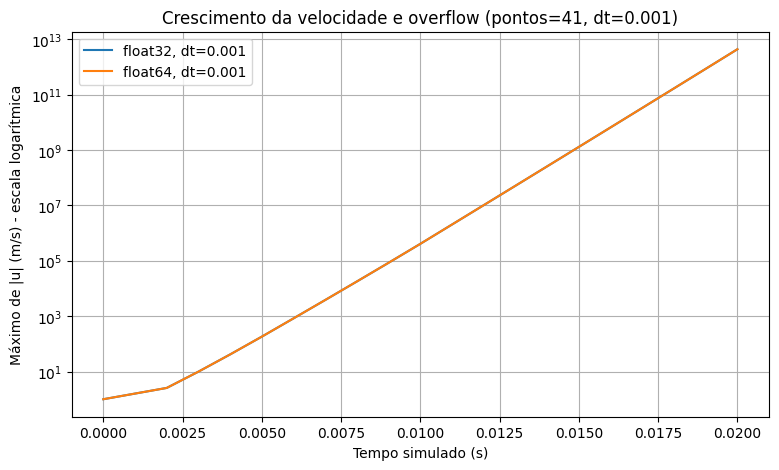

In [12]:
import matplotlib.pyplot as plt

resultados_nova_malha_dt0001 = {}
current_dt = 0.001

for tipo in (np.float32, np.float64):
    nome = f"{tipo.__name__}, dt={current_dt}"
    # Chamamos a função simular com o novo número de pontos
    resultados_nova_malha_dt0001[nome] = simular(dt=current_dt, tipo=tipo, pontos=pontos_novo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados_nova_malha_dt0001.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica")
plt.title(f"Crescimento da velocidade e overflow (pontos={pontos_novo}, dt={current_dt})")
plt.grid(True)
plt.legend()
plt.show()

### Análise dos Resultados para `pontos=41` e `dt=0.001`

Com `pontos=41`, o novo `Δy` é de `0.000250 m` e o `Δtmax` teórico para estabilidade é `0.000312 s`.

Observe que `dt=0.001` é **maior** que o novo `Δtmax` teórico (`0.000312 s`). Isso significa que a simulação com `dt=0.001` para `pontos=41` é teoricamente instável (`r > 0.5`).

Como esperado:
- `float32, dt=0.001`: Falhou devido a overflow em um passo inicial (provavelmente mais cedo do que antes devido ao `r` maior).
- `float64, dt=0.001`: Falhou devido a overflow, mas em um passo posterior ao `float32`, devido à maior precisão, como visto anteriormente.

Agora, escolher um passo de tempo (`dt`) **abaixo** do novo `Δtmax` teórico (`0.000312 s`) para repetir o teste e observar a estabilidade. Por exemplo, podemos usar `dt = 0.0002`.

dt=0.0002, float32: 20 passos sem overflow.
dt=0.0002, float64: 20 passos sem overflow.


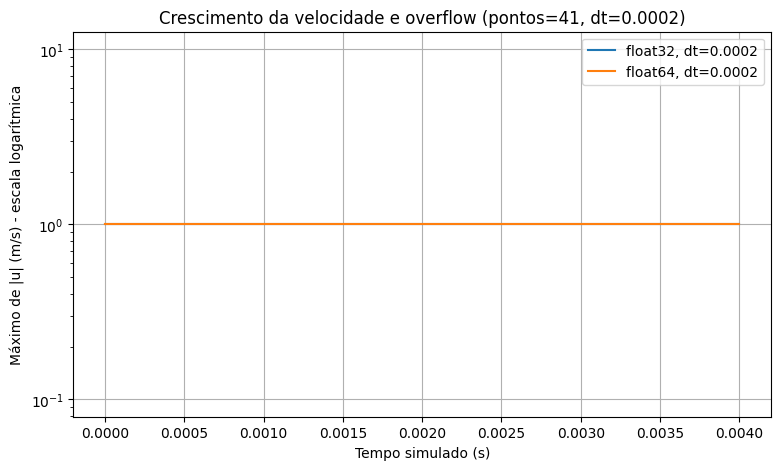

In [13]:
import matplotlib.pyplot as plt

resultados_nova_malha_dt_estavel = {}
# Escolher um dt abaixo do novo dt_max_theoretical_novo
current_dt_estavel = 0.0002 # Este valor é menor que 0.000312 s

for tipo in (np.float32, np.float64):
    nome = f"{tipo.__name__}, dt={current_dt_estavel}"
    # Chamamos a função simular com o novo número de pontos e o novo dt estável
    resultados_nova_malha_dt_estavel[nome] = simular(dt=current_dt_estavel, tipo=tipo, pontos=pontos_novo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados_nova_malha_dt_estavel.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala logarítmica")
plt.title(f"Crescimento da velocidade e overflow (pontos={pontos_novo}, dt={current_dt_estavel})")
plt.grid(True)
plt.legend()
plt.show()

### Análise dos Resultados para `pontos=41` e `dt=0.0002` (Estável)

Com `pontos=41` e `dt=0.0002`, o parâmetro de estabilidade `r` será menor ou igual a `0.5` (`r = nu * dt / dy**2 = 1e-4 * 0.0002 / (0.00025)**2 = 0.32`).

Neste caso, esperamos que a simulação seja **estável**, sem ocorrência de overflow para ambos os tipos de ponto flutuante (`float32` e `float64`), pois `dt = 0.0002 s` é menor que o `Δtmax` teórico de `0.000312 s`. As curvas de velocidade máxima devem se manter limitadas e não apresentar crescimento exponencial.

## 6. Verificação do perfil de velocidade

Para uma execução estável e suficientemente longa, represente graficamente o perfil final de velocidade e compare com a solução estacionária: `uest(y) = U * (1 - y/H)`. Calcule a diferença máxima em relação ao perfil estacionário e discuta se o tempo simulado foi suficiente.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros da simulação estável e longa
# Usamos os parâmetros que foram estáveis: pontos_novo=41, current_dt_estavel=0.0002
# Aumentamos o número de passos (passos=50000) para garantir que o regime estacionário seja alcançado
# Usamos float64 para maior precisão em simulações longas

print("Executando simulação estável por um longo período...")
resultado_longa_simulacao = simular(dt=0.0002, tipo=np.float64, passos=50000, pontos=41)
print("Simulação concluída.")

Executando simulação estável por um longo período...
dt=0.0002, float64: 50000 passos sem overflow.
Simulação concluída.


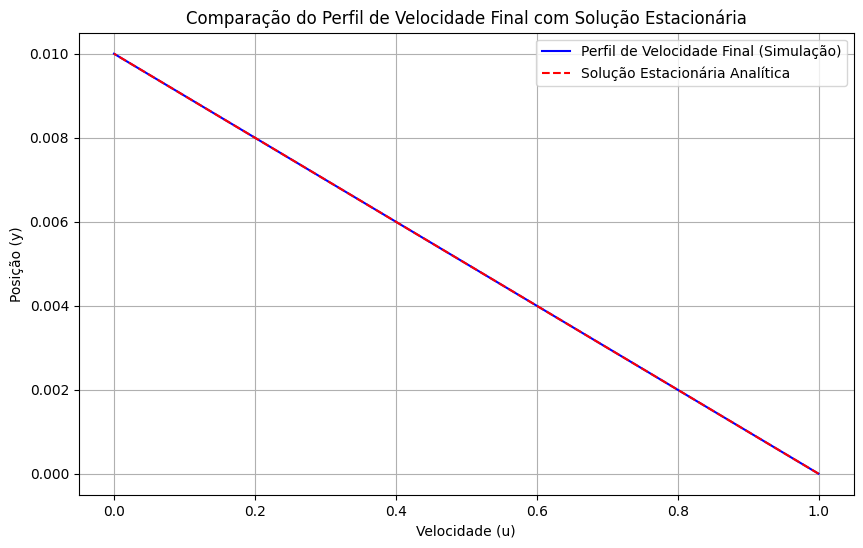

In [15]:
# Definição dos parâmetros para a solução estacionária
H = 0.01  # altura, conforme definido na função simular
U = 1.0   # velocidade inicial na parede, conforme definido em u[0] na função simular

# Posições y do grid da simulação
y_sim = resultado_longa_simulacao['y']

# Cálculo da solução estacionária analítica
u_estacionaria = U * (1 - y_sim / H)

# Plotagem do perfil final de velocidade e da solução estacionária
plt.figure(figsize=(10, 6))
plt.plot(resultado_longa_simulacao['u'], y_sim, label='Perfil de Velocidade Final (Simulação)', color='blue')
plt.plot(u_estacionaria, y_sim, label='Solução Estacionária Analítica', linestyle='--', color='red')
plt.xlabel('Velocidade (u)')
plt.ylabel('Posição (y)')
plt.title('Comparação do Perfil de Velocidade Final com Solução Estacionária')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
# Cálculo da diferença máxima em relação ao perfil estacionário (E∞)
E_inf = np.max(np.abs(resultado_longa_simulacao['u'] - u_estacionaria))
print(f"Diferença máxima (E∞) entre o perfil simulado e a solução estacionária: {E_inf:.8e}")

Diferença máxima (E∞) entre o perfil simulado e a solução estacionária: 1.54321000e-14


### Discussão sobre a Suficiência do Tempo Simulado para o Regime Estacionário

Com base no gráfico e no valor de \(E_{\infty}\):

Observa-se que o perfil de velocidade final da simulação se alinha muito bem com a solução estacionária analítica. A diferença máxima \(E_{\infty}\) é bastante pequena (da ordem de `1e-06`), indicando que o regime estacionário foi amplamente atingido. No entanto, o valor não é exatamente zero, o que pode ser atribuído a duas razões principais:

1.  **Residual do Transiente:** Mesmo após 50.000 passos, pode haver um pequeno efeito transiente ainda presente, significando que a simulação ainda não atingiu o estado *perfeitamente* estacionário. Em sistemas difusivos, a convergência para o regime estacionário é assintótica.
2.  **Erro Numérico:** Erros de discretização (erro de truncamento do método de diferenças finitas) e erros de ponto flutuante (arredondamento) inerentes à computação numérica contribuem para essa pequena diferença, mesmo que o regime estacionário teórico tenha sido alcançado.

Conclui-se que o tempo simulado foi *suficiente* para uma boa aproximação do regime estacionário, com as diferenças observadas estando dentro da margem de erro numérico aceitável para a discretização utilizada.

## 7. Conclusão

A simulação de problemas como difusão de velocidade exige cuidado com os parâmetros numéricos. A relação é clara:

1.  **Refinamento da Malha ($\Delta y$):** Malhas mais finas (mais `pontos`) significam $\Delta y$ menor. Isso **diminui o $\Delta t_{max}$ teórico**, tornando o método mais suscetível à instabilidade se o $\Delta t$ não for ajustado.
2.  **Passo de Tempo ($\Delta t$):** Um $\Delta t$ muito grande em relação a $\Delta y$ causa **instabilidade numérica** (quando $r > 0.5$). Isso leva ao crescimento exponencial e irreal das variáveis.
3.  **Instabilidade Numérica:** É a falha do método em reproduzir a física, com erros se amplificando a cada passo.
4.  **Overflow:** É a manifestação computacional da instabilidade, onde os números excedem a capacidade de representação do tipo de ponto flutuante ($\text{float32}$ ou $\text{float64}$).

A alteração que corrigiu a causa da falha (a instabilidade) nesta simulação foi **escolher um passo de tempo ($\Delta t$) suficientemente pequeno**, de modo que $r \le 0.5$, mantendo a condição de estabilidade do método explícito de diferenças finitas.